# Burgers Equation

Given the Burgers’ equation in 1D $ \frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0 $ build a numerical code to solve it on a grid
with extent x ∈ [0, 10] and with initial conditions given by
$$ u(x, t = 0) = 10 e^{−(x−x_0)^2} \, \, , $$
with $x_0 = 5$. Compute the solution using both the flux-conservative and the non flux-
conservative versions of the upwind scheme. Use Courant factor $cf = 0.5$, a grid with at least
$J = 101$ points with periodic boundary conditions, and terminate the evolution at $t = 0.5$.
Compare the solutions computed with the two different methods by plotting $u(x, t)$ at different
times (including $t = 0.5$). What happens when you increase the resolution?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(['science', 'grid', 'high-contrast', 'no-latex'])

In [2]:
#domain ---------------------------
L = 10.0         #domain length
nx = 101         #number of points
dx = L/(nx-1)    #grid space
x = np.linspace(0, L, nx)

#initial conditions ---------------
x0 = 5
u_initial = 10 * np.exp(- (x - x0)**2 )
u_current = np.copy(u_initial)

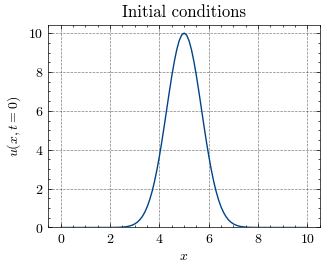

In [3]:
plt.plot(x, u_initial)
plt.xlabel("$x$")
plt.ylabel("$u(x, t=0)$")
plt.ylim(0, 10.4)
plt.title("Initial conditions")
plt.savefig('initial.png', dpi=200)
plt.show()

Unlike the Advection equation, the solution is not the same function moving at a constant speed a. Thus the time step is not a constant anymore in theory, and should evolve in time. For now, we can select the maximum of $u(t=0, x)$ and use it as a constant speed. Since the time step is inversely proportional to the speed, using the maximum speed guarantees that the CFL condition is satified everywhere.
This works because we know that the maximum is going down, otherwise we should recompute the dt at each iteration.

In [4]:
#time step ------------------------
cf = 0.5
a = np.max(u_current)
dt = cf * dx/a
t_final = 0.5

time = []
time.append(0.0)

print('nx=',nx)
print('dx=',dx)
print('dt=',dt)
print('Number of iterations=',t_final/dt)

nx= 101
dx= 0.1
dt= 0.005
Number of iterations= 100.0


In [5]:
import os
##create directory where to save images
print(os.getcwd())

#os.makedirs('./FC_images')

os.listdir('./')

C:\Users\lm101\Desktop\Uni\numerical_relativity_2025\Burgers


['.ipynb_checkpoints',
 'Burgers_Equation.ipynb',
 'FC_images',
 'final.png',
 'initial.png',
 'NFC_images']

## Flux-conservative form
The Burgers equation can be written either in a conservative or a non conservative form. The two are mathematically equivalent, but applying a numerical method will yield different results.

In [58]:
t = 0.0
i = 0

FC_l2norm = []
FC_l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))

u_current = np.copy(u_initial)

#saving the initial conditions in an img
plt.plot(x, u_current)
plt.ylim(0, 10.4)
plt.title('Time='+str(round(t,2)))
plt.savefig('./FC_images/fig_'+str(i).zfill(5)+'.png', dpi=200)
plt.close()

while t <= t_final:
    u_next = u_current - dt/(2*dx) *(u_current**2 - np.roll(u_current, +1)**2)
    u_current = u_next.copy()

    t += dt
    i += 1
    
    FC_l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))
    time.append(t)

    if (i == 40): fc_u_10 = u_current.copy()
    if (i == 60) : fc_u_30 = u_current.copy()
        
#plot the current result and save in an image every 5 iterations
    if (i%5==0):
        plt.plot(x, u_current)
        plt.ylim(0, 10.4)
        plt.title('Time='+str(round(t,2)))
        plt.savefig('./FC_images/fig_'+str(i).zfill(5)+'.png', dpi=200)
        plt.close()

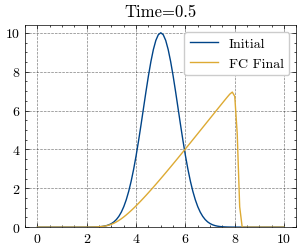

In [59]:
# Plot the final solution
plt.plot(x, u_initial, label='Initial')
plt.plot(x, u_current, label='FC Final')
plt.ylim(0, 10.4)
plt.title('Time='+str(round(t,2)))
plt.legend()
plt.show()

FC_final = u_current.copy()

## Non-flux conservative form

In [60]:
##create directory where to save images
print(os.getcwd())

#os.makedirs('./NFC_images')

os.listdir('./')

C:\Users\lm101\Desktop\Uni\numerical_relativity_2025\Burgers


['.ipynb_checkpoints',
 'Burgers_Equation.ipynb',
 'FC_images',
 'FC_movie.mp4',
 'final.png',
 'initial.png',
 'NFC_images',
 't0_1.png',
 't0_3.png']

In [70]:
t = 0.0
i = 0

time = []
time.append(0.0)

u_current = u_initial.copy()

NFC_l2norm = []
NFC_l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))

#saving the initial conditions in an img
plt.plot(x, u_current)
plt.ylim(0, 10.4)
plt.title('Time='+str(round(t,2)))
plt.savefig('./NFC_images/fig_'+str(i).zfill(5)+'.png', dpi=200)
plt.close()

while t <= t_final:
    u_next = u_current - dt/dx * u_current * (u_current - np.roll(u_current, +1))
    u_current = u_next.copy()

    t += dt
    i += 1
    
    NFC_l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))
    time.append(t)

    if (i == 40): nfc_u_10 = u_current.copy()
    if (i == 60): nfc_u_30 = u_current.copy()
        
#plot the current result and save in an image every 5 iterations
    if (i%5==0):
        plt.plot(x, u_current)
        plt.ylim(0, 10.4)
        plt.title('Time='+str(round(t,2)))
        plt.savefig('./NFC_images/fig_'+str(i).zfill(5)+'.png', dpi=200)
        plt.close()

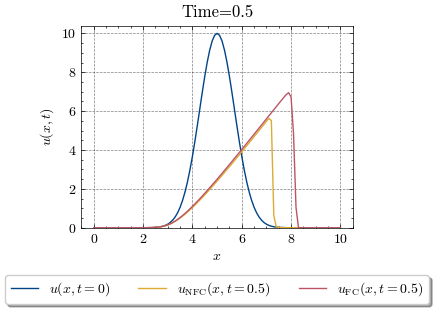

In [71]:
# Plot the final solution
plt.plot(x, u_initial, label='$u(x, t=0)$')
plt.plot(x, u_current, label='$u_\mathrm{NFC} (x, t = 0.5)$')
plt.plot(x, FC_final, label = '$u_\mathrm{FC} (x, t = 0.5)$')
plt.ylim(0, 10.4)
plt.title('Time='+str(round(t,2)))
plt.xlabel('$x$')
plt.ylabel('$u(x, t)$')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),
          fancybox=True, shadow=True, ncol=3)
plt.savefig('final.png', dpi=200)
plt.show()

We expect both forms to show a shock and a rarefaction wave, but thanks to the Lax-Wendroff and the Hou-Le Flock Theorems we already know that the flux-conservative form is the only correct one. Also notice that the maximum goes down as expected, so our choice of fixing $a = u_{max}(t=0, x)$ is justified.

In [72]:
from moviepy import ImageSequenceClip

clip = ImageSequenceClip('./FC_images/', fps = 7)
clip.write_videofile('FC_movie.mp4')
clip.close()

MoviePy - Building video FC_movie.mp4.
MoviePy - Writing video FC_movie.mp4



MoviePy - Done !
MoviePy - video ready FC_movie.mp4


In [73]:
# don't worry about the code in this cell, it is just to let you 
# display the movies you generated above in Jupyter notebook
from IPython.display import HTML

HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="./FC_movie.mp4" type="video/mp4">
</video></div>""")

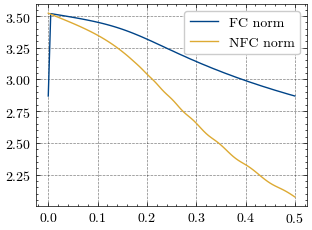

In [74]:
plt.plot(time, FC_l2norm, label = "FC norm")
plt.plot(time, NFC_l2norm, label = "NFC norm")
plt.legend()
plt.show()

In [75]:
save_intermediate = False

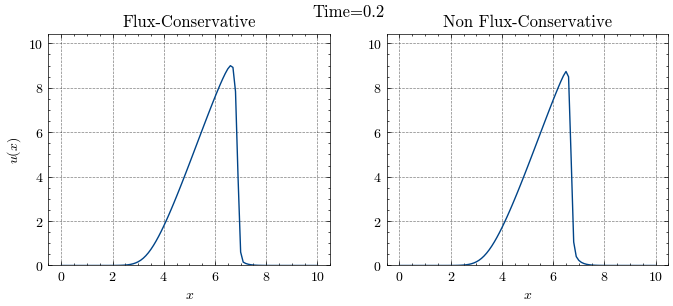

In [83]:
fig, ax = plt.subplots(1, 2, figsize = (8,3))
ax[0].plot(x, fc_u_10)
ax[0].set(xlabel = "$x$", ylabel = "$u(x)$", title = "Flux-Conservative", ylim = [0, 10.4])

ax[1].plot(x, nfc_u_10)
ax[1].set(xlabel = "$x$", title = "Non Flux-Conservative", ylim = [0, 10.4])

plt.suptitle('Time='+str(round(time[40],2)))
if (save_intermediate):plt.savefig('t0_2.png', dpi = 200)
plt.show()

In [77]:
i_fcmax = np.where(fc_u_30 == max(fc_u_30))[0][0]
print('flux conservative max at t = 0.3: ', i_fcmax, fc_u_30[i_fcmax])

i_nfcmax = np.where(nfc_u_30 == max(nfc_u_30))[0][0]
print('non flux conservative max at t = 0.3: ', i_nfcmax, nfc_u_30[i_nfcmax])

flux conservative max at t = 0.3:  71 8.24468468750943
non flux conservative max at t = 0.3:  68 7.531021058130082


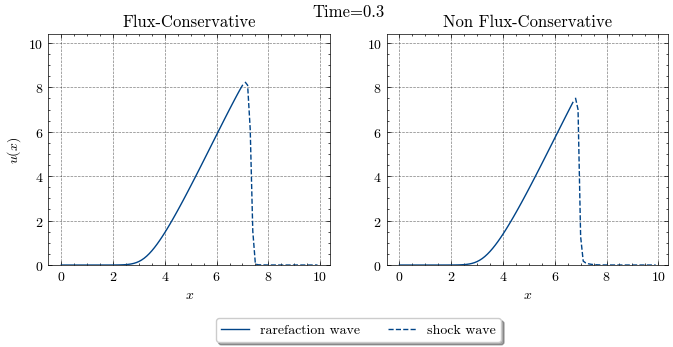

In [78]:
fig, ax = plt.subplots(1, 2, figsize = (8,3))
ax[0].plot(x[0:i_fcmax], fc_u_30[0:i_fcmax], color = 'C0', label = 'rarefaction wave')
ax[0].plot(x[i_fcmax:nx-1], fc_u_30[i_fcmax:nx-1], linestyle = 'dashed', color = 'C0', label = 'shock wave')
ax[0].set(xlabel = "$x$", ylabel = "$u(x)$", title = "Flux-Conservative", ylim = [0, 10.4])
ax[0].legend(loc='upper center', bbox_to_anchor=(1.1, -0.2),
          fancybox=True, shadow=True, ncol=2)

ax[1].plot(x[0:i_nfcmax], nfc_u_30[0:i_nfcmax], color = 'C0')
ax[1].plot(x[i_nfcmax:nx-1], nfc_u_30[i_nfcmax:nx-1], linestyle = 'dashed', color = 'C0')
ax[1].set(xlabel = "$x$", title = "Non Flux-Conservative", ylim = [0, 10.4])

plt.suptitle('Time='+str(round(time[60],2)))
if (save_intermediate): plt.savefig('t0_3.png', dpi = 200)
plt.show()